In [1]:
import os.path
from scipy import *
import numpy as np
from numpy import *
from numpy import linalg as LA
from scipy import linalg as LA2
import sympy as sympy
import sys as sys
import time
import matplotlib as mpl
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import itertools as it
from mpl_toolkits.mplot3d import Axes3D
from IPython.core.display import HTML


sys.path.append('/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/')
from Modules import BasicTools as BT
from Modules import WaveTools as WT
from Modules import PlotTools as PT
from Modules import FFTTools as FFTT
from Modules import OperatorTools as OT
from Modules import GridTransferTools as GTT
from Modules import TestTools as TT
from Modules import SolverTools as ST
from Modules import WaveformTools as WFT

display(HTML("<style>pre { white-space: pre !important; }</style>"))
np.set_printoptions( linewidth = 10000, threshold = 100000)

In [2]:
plot ='gauss'
colors = True
transparent = True

x_0 = 0.
x_1 = 0.5
if (plot == 'gauss'):
    nh_min = 256
    locs = []
    epsilons = [1]
    mus = [1]
else:
    nh_min = 512
    locs = [x_1]
    epsilons = [1, 0.3]
    mus = [1, 0.3]
    if (plot == 'notgauss'):
        nh_min = 64
        epsilons = [0.5, 1]
        mus = [0.5, 1]

In [3]:

refRatio = 2
CFL = np.sqrt(0.5)
nt = 20

Hans = False

deriv = 'CD'
RK = 4
order = 2

L = 1.

In [4]:
omega = BT.Grid(nh_min)
physics = BT.PhysProps(omega, epsilons, mus, locs = locs)

xCell = omega.xCell
xNode = omega.xNode
cs = physics.cs

In [5]:
t_f = 0.4
t = np.linspace(0, t_f, num = nh_min + 1)

[0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.       

/var/folders/t3/h7gwl8v56_z3991b7qk6sm480000gn/T/ipykernel_39010/812655018.py:23: RuntimeWarning: invalid value encountered in sqrt
  eyeL = eyeH * ((1 - ((XL/ eyeW))**2)**0.5)
/var/folders/t3/h7gwl8v56_z3991b7qk6sm480000gn/T/ipykernel_39010/812655018.py:24: RuntimeWarning: invalid value encountered in sqrt
  eyeR = eyeH * ((1 - ((XR/ eyeW))**2)**0.5)


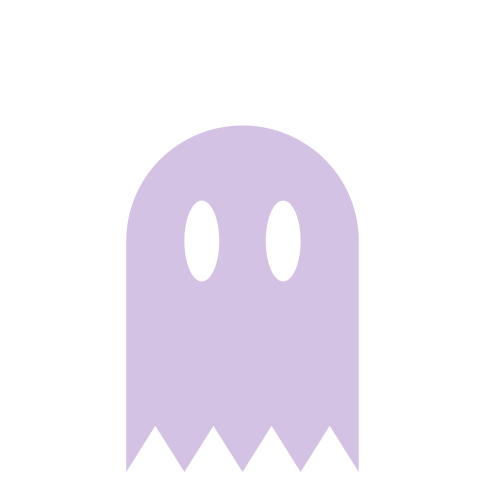

In [6]:
n = 10000
color = PT.ColorDefault(4)
alpha = 0.4

r = 1
eyeW = 0.15 * r
eyeH = 0.35 * r
eyeD = 0.55 * r
H = 2 * r
zags = 4
zagH = 0.4 * r

per = (2 * r) / zags

X = np.linspace(-r, r, num = n)

head = ((r**2) - (X**2))**0.5

# eyeLX = np.linspace(-eyeW/2, eyeW/2, num = n)

XL = X + ((eyeW + eyeD) / 2)
XR = X - ((eyeW + eyeD) / 2)
eyeL = eyeH * ((1 - ((XL/ eyeW))**2)**0.5)
eyeR = eyeH * ((1 - ((XR/ eyeW))**2)**0.5)
eyeL[np.isnan(eyeL)] = 0
eyeR[np.isnan(eyeR)] = 0
eyes = eyeL + eyeR
minEyes = min(eyeL)
print(eyes)

sideX = r * np.ones(2, float)
sideY = np.asarray([-H, 0])

Xper = X / per

skirt = 2 * zagH * abs(Xper - np.floor(Xper + 0.5)) - H


fig, ax = plt.subplots(figsize = [6, 6])
# plt.plot(X, head, color = color, alpha = alpha)
# plt.plot(X, eyes, color = color, alpha = alpha)
# plt.plot(X, -eyes, color = color, alpha = alpha)
# plt.plot(sideX, sideY, color = color, alpha = alpha)
# plt.plot(-sideX, sideY, color = color, alpha = alpha)
# plt.plot(X, skirt, color = color, alpha = alpha)
ax.fill_between(X, eyes, head, facecolor = color, alpha = alpha)
ax.fill_between(X, skirt, -eyes, facecolor = color, alpha = alpha)
ax.axis('off')
# ax.grid(True)
plt.xlim(-2, 2)
plt.ylim(-2, 2)

plt.show()
saveName = '/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/Figures/Ghost' + str(alpha)# + appendage
fig.savefig(saveName + '.png', bbox_inches = 'tight', dpi = 300, transparent = transparent)

In [7]:
fontsize = 14
if (locs != []):
    vecs = [[0, 0, 0, 1], [0, 0, 0, -1], [0, 0, 1.8, 0]]
    X, Y, DX, DY = zip(*vecs)
    fig, ax = plt.subplots(figsize = [6, 6])
    plt.xlim(-0.05, 0.5)
    plt.ylim(-1.25, 1.25)
    
    ax.quiver(X, Y, DX, DY, color = 'k', scale = 2.25, zorder = 2)#, arrow_length_ratio = 0.075)
    for x_f in (xNode[::4]):
        x_1 = x_f - (cs[1] * t_f)
        x_c2 = (cs[1] * t) + x_1
        x_c2[x_c2 <= locs[0]] = 0
        x_0 = (((cs[1] - cs[0]) * locs[0]) + (cs[0] * x_1)) / cs[1]
        x_c1 = (cs[0] * t) + x_0
        x_c1[x_c1 > locs[0]] = 0
        x = np.asarray(x_c1) + np.asarray(x_c2)
        if ((x > locs[0]).all()):
            color = PT.ColorDefault(1)
        else:
            if ((x <= locs[0]).all()):
                color = PT.ColorDefault(6)
            else:
                color = PT.ColorDefault(3)
        if (x[-1] > 0):
            if (colors):
                plt.plot(t, x, color = color, linestyle = '--', zorder = 1)
            else:
                plt.plot(t, x, color = PT.ColorDefault(0), linestyle = '--', zorder = 1)
            # plt.text(1.01 * t_f, x[-1], r'$x$')
            print(x[-1])
    t_s = np.asarray([0, t_f])
    x_s = locs[0] * np.ones(2, float)
    x_top = np.ones(2, float)
    t_fl = t_f * np.ones(2, float)
    x_tf = np.asarray([0, 1])
    
    plt.plot(t_s, x_s, color = PT.ColorDefault(2), linestyle = '-', zorder = 0)
    plt.plot(t_s, x_top, color = PT.ColorDefault(2), linestyle = '-', zorder = 0)
    plt.plot(t_fl, x_tf, color = PT.ColorDefault(2), linestyle = '-', zorder = 0)
    plt.text(-0.035, locs[0], r'$x_{h}$', fontsize = fontsize)#, color = PT.ColorDefault(3))
    plt.text(-0.025, 0.95, '1', fontsize = fontsize)#, color = PT.ColorDefault(3))
    plt.text(0.41, 0.25, r'$\frac{\mathrm{d} x}{\mathrm{d} t} = c_{1}$', fontsize = fontsize)
    plt.text(0.41, 0.75, r'$\frac{\mathrm{d} x}{\mathrm{d} t} = c_{2}$', fontsize = fontsize)
    plt.text(t_f-0.005, -0.125, r'$t$', fontsize = fontsize)#, color = PT.ColorDefault(3))
    plt.text(1.11 * t_f, -0.025, r'$t$', fontsize = fontsize)
    plt.text(-0.01, 1.17, r'$x$', fontsize = fontsize)
    plt.axis('off')
    plt.show()
    saveName = '/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/Figures/MultMedCharLines' # + appendage
    fig.savefig(saveName + '.png', bbox_inches = 'tight', dpi = 600, transparent = transparent)
    

[20, 43, 64, 85, 107]

YOU ARE RUNNING GAUSS! False

[1.58113883e-04 2.02997417e-04 2.59598414e-04 3.30677446e-04 4.19563915e-04 5.30252469e-04 6.67510783e-04 8.36998900e-04 1.04540002e-03 1.30056223e-03 1.61165020e-03 1.98930535e-03 2.44581233e-03 2.99526895e-03 3.65375595e-03 4.43950206e-03 5.37303914e-03 6.47734102e-03 7.77793905e-03 9.30300651e-03 1.10834031e-02 1.31526708e-02 1.55469709e-02 1.83049538e-02 2.14675511e-02 2.50776818e-02 2.91798655e-02 3.38197350e-02 3.90434449e-02 4.48969744e-02 5.14253239e-02 5.86716109e-02 6.66760716e-02 7.54749810e-02 8.50995053e-02 9.55745088e-02 1.06917336e-01 1.19136599e-01 1.32231001e-01 1.46188223e-01 1.60983922e-01 1.76580864e-01 1.92928233e-01 2.09961153e-01 2.27600457e-01 2.45752715e-01 2.64310573e-01 2.83153388e-01 3.02148195e-01 3.21150988e-01 3.40008313e-01 3.58559162e-01 3.76637128e-01 3.94072791e-01 4.10696296e-01 4.26340055e-01 4.40841533e-01 4.54046035e-01 4.65809440e-01 4.76000819e-01 4.84504851e-01 4.91223997e-01 4.96080362e-01 4

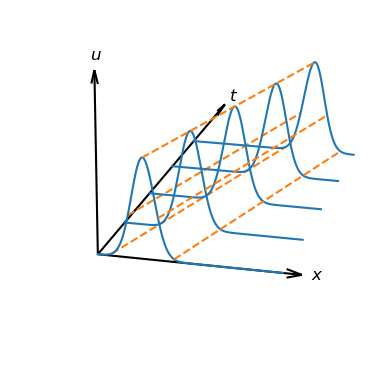

In [8]:
if (locs == []):
    t_f = 1.
    t_snaps = 5
    sigma, mu = WFT.GaussParams(x_0, x_1)
    sigma = 2 * sigma
    t_f = (1. - (2. * mu)) / cs[0]
    vecs = [0, 0, 1]
    args = [sigma, mu]
    
    vecs = np.array([[0, 0, 0, 1.1, 0, 0], [0, 0, 0, 0, 0.7, 0], [0, 0, 0, 0, 0, 0.9]])
    X, Y, Z, DX, DY, DZ = zip(*vecs)
    
    #waveInit = WFT.InitCond(omega, physics, WFT.Gauss, args)#, cellAve = False)
    t = np.zeros(nh_min + 1)
    js = [((nh_min / 4) - 2) / 3, ((nh_min / 2) + 1) / 3, nh_min / 4, (nh_min - 1) / 3, (((5 * nh_min) / 4) + 2) / 3]# nh_min / 2]#, ((2 * nh_min) + 1) / 3]#, (((5 * nh_min) / 2) + 2) / 3]
    js = [int(j) for j in js]
    print(js)
    # fig, ax = plt.subplots()
    fig = plt.figure()
    ax = fig.add_subplot(111, projection = '3d')
    ax.view_init(20, 285)#(30, 285)
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$t$')
    ax.set_zlabel(r'$u$')
    ax.axis('off')
    ax.quiver(X, Y, Z, DX, DY, DZ, color = 'k', arrow_length_ratio = 0.075, zorder = 0)
    ax.text(1.15, 0, -0.02, r'$x$', fontsize = fontsize-2)
    ax.text(0, 0.725, 0, r'$t$', fontsize = fontsize-2)
    ax.text(-0.02, 0, 0.95, r'$u$', fontsize = fontsize-2)
    ts = np.zeros((2, t_snaps), float)
    xs = np.zeros((2, t_snaps), float)
    us = np.zeros((2, t_snaps), float)
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.1, 0.21)
    ax.set_zlim(-0.1, 0.7)
    
    for i in range(t_snaps):
        t_val = (i * t_f) / (t_snaps - 1)
        t = t_val * np.ones(nh_min + 1)
        waveProp = 0.5 * WFT.Advect(omega, physics, WFT.Gauss, args, t_val, cellAve = False, field = 'E')
        if (i == 0):
            ts[0, :] = t_val * np.ones(t_snaps)
            xs[0, :] = xNode[js]
            print(waveProp)
            print('')
            us[0, :] = waveProp[js]
        else:
            if (i == t_snaps - 1):
                ts[1, :] = t_val * np.ones(t_snaps)
                xShift = WFT.ShiftX(omega, physics, -t_val)
                xs[1, :] = xShift[js]
                us[1, :] = us[0, :]
        ax.plot(xNode, t, waveProp, color = PT.ColorDefault(0), zorder = 20)
    print(us)
    for i in range(t_snaps):
        zorder = i * 10
        ax.plot(xs[:, i], ts[:, i], us[:, i], color = PT.ColorDefault(1), linestyle = '--', zorder = zorder)
    plt.show()
    saveName = '/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/Figures/GaussianCharLines' # + appendage
    fig.savefig(saveName + '.png', bbox_inches = 'tight', dpi = 600, transparent = transparent)
    

0.0625
0.125
0.1875
0.25
0.3125
0.375
0.4375
0.5
0.5625
0.625
0.6875
0.75
0.8125
0.875
0.9375
1.0


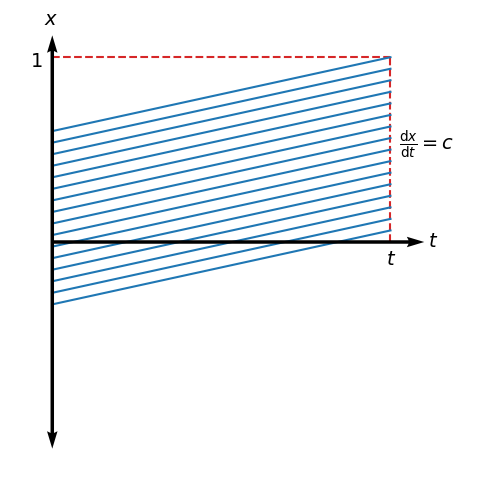

In [9]:
if (locs == []):
    t_f = 0.4
    t = np.linspace(0, t_f, num = nh_min + 1)
    vecs = [[0, 0, 0, 1], [0, 0, 0, -1], [0, 0, 1.8, 0]]
    X, Y, DX, DY = zip(*vecs)
    fig, ax = plt.subplots(figsize = [6, 6])
    plt.xlim(-0.05, 0.5)
    plt.ylim(-1.25, 1.25)
    
    ax.quiver(X, Y, DX, DY, color = 'k', scale = 2.25, zorder = 2)#, arrow_length_ratio = 0.075)
    for x_f in (xNode[::16]):
        x_1 = x_f - (cs[0] * t_f)
        x_c1 = (cs[0] * t) + x_1
        x = np.asarray(x_c1)
        if (x[-1] > 0):
            plt.plot(t, x, color = PT.ColorDefault(0), zorder = 1)
            # plt.text(1.01 * t_f, x[-1], r'$x$')
            print(x[-1])
    t_s = np.asarray([0, t_f])
    x_top = np.ones(2, float)
    t_fl = t_f * np.ones(2, float)
    x_tf = np.asarray([0, 1])
    
    plt.plot(t_s, x_top, color = PT.ColorDefault(3), linestyle = '--', zorder = 0)
    plt.plot(t_fl, x_tf, color = PT.ColorDefault(3), linestyle = '--', zorder = 0)
    plt.text(-0.025, 0.95, '1', fontsize = fontsize)#, color = PT.ColorDefault(3))
    plt.text(t_f-0.005, -0.125, r'$t$', fontsize = fontsize)#, color = PT.ColorDefault(3))
    plt.text(0.41, 0.5, r'$\frac{\mathrm{d} x}{\mathrm{d} t} = c$', fontsize = fontsize)
    plt.text(1.11 * t_f, -0.025, r'$t$', fontsize = fontsize)
    plt.text(-0.01, 1.175, r'$x$', fontsize = fontsize)
    plt.axis('off')
    plt.show()
    saveName = '/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/Figures/SingMedCharLines' # + appendage
    fig.savefig(saveName + '.png', bbox_inches = 'tight', dpi = 600, transparent = transparent)
    

(24,)
(24,)
[ 0.00000000e+00  2.45042851e-02  4.87725805e-02  7.25711693e-02  9.56708581e-02  1.17849184e-01  1.38892558e-01  1.58598321e-01  1.76776695e-01  1.93252613e-01  2.07867403e-01  2.20480316e-01  2.30969883e-01  2.39235084e-01  2.45196320e-01  2.48796182e-01  2.50000000e-01  2.48796182e-01  2.45196320e-01  2.39235084e-01  2.30969883e-01  2.20480316e-01  2.07867403e-01  1.93252613e-01  1.76776695e-01  1.58598321e-01  1.38892558e-01  1.17849184e-01  9.56708581e-02  7.25711693e-02  4.87725805e-02  2.45042851e-02  3.06161700e-17 -2.45042851e-02 -4.87725805e-02 -7.25711693e-02 -9.56708581e-02 -1.17849184e-01 -1.38892558e-01 -1.58598321e-01 -1.76776695e-01 -1.93252613e-01 -2.07867403e-01 -2.20480316e-01 -2.30969883e-01 -2.39235084e-01 -2.45196320e-01 -2.48796182e-01 -2.50000000e-01 -2.48796182e-01 -2.45196320e-01 -2.39235084e-01 -2.30969883e-01 -2.20480316e-01 -2.07867403e-01 -1.93252613e-01 -1.76776695e-01 -1.58598321e-01 -1.38892558e-01 -1.17849184e-01 -9.56708581e-02 -7.25711693

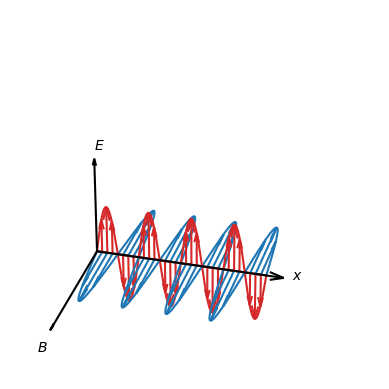

In [10]:
if (locs == []):
    vecs = [0, 0, 1]
    args = [sigma, mu]
    k = 7
    
    xs = np.linspace(0, 1, num = 33)
    e = 0.25 * WT.NodeWaves(16, xs, nRes = 33, ct = 0, scale = 1)[:, k]
    
    xs = xs[np.mod(np.arange(xs.size), 4) != 0]
    e = e[np.mod(np.arange(e.size), 4) != 0]
    
    e1 = e + 0
    e1[e1 < 0] = 0
    e1 = np.ma.masked_invalid(e1, 0)
    e2 = e - e1
    
    b = -0.5 * e
    b1 = b + 0
    b1[b1 < 0] = 0
    b1 = np.ma.masked_invalid(b1, 0)
    b2 = b - b1
    
    print(np.shape(xs))
    
    zer = 0 * xs
    
    
    print(np.shape(e))
    
    
    vecs = np.array([[0, 0, 0, 1.1, 0, 0], [0, 0, 0, 0, -0.2, 0], [0, 0, 0, 0, 0, 0.5]])
    X, Y, Z, DX, DY, DZ = zip(*vecs)
    
    #waveInit = WFT.InitCond(omega, physics, WFT.Gauss, args)#, cellAve = False)
    t = np.zeros(nh_min + 1)
    js = [((nh_min / 4) - 2) / 3, ((nh_min / 2) + 1) / 3, nh_min / 4, (nh_min - 1) / 3, (((5 * nh_min) / 4) + 2) / 3]# nh_min / 2]#, ((2 * nh_min) + 1) / 3]#, (((5 * nh_min) / 2) + 2) / 3]
    js = [int(j) for j in js]
    # fig, ax = plt.subplots()
    fig = plt.figure()
    ax = fig.add_subplot(111, projection = '3d')#, computed_zorder=False)
    ax.view_init(30, 285)
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$t$')
    ax.set_zlabel(r'$u$')
    ax.axis('off')
    
    ax.text(1.15, 0, 0, r'$x$')
    ax.text(0, -0.25, 0, r'$B$')
    ax.text(0, 0, 0.55, r'$E$')
    ax.set_xlim(-0.1, 1.2)
    ax.set_ylim(-0.1, 0.21)
    ax.set_zlim(-0.1, 0.7)
    
    E = 0.25 * WT.MakeNodeWaves(omega)[:, k] # WFT.InitCond(omega, physics, WFT.Gauss, args, t_val, cellAve = False, field = 'E')
    E1 = E + 0
    E1[E1 < 0] = 0
    E1 = np.ma.masked_invalid(E1, 0)
    E2 = E - E1
#     E2 = np.ma.masked_invalid(E2, 0)
    print(E)
    print(E1)
    print(E2)
    B = -0.5 * E
    B1 = B + 0
    B1[B1 < 0] = 0
    B1 = np.ma.masked_invalid(B1, 0)
    B2 = B - B1
    zero = 0 * E
    
    plt.quiver(xs, zer, zer, zer, zer, e1, color = PT.ColorDefault(3), zorder = 2)
    ax.quiver(xs, zer, zer, zer, zer, e2, color = PT.ColorDefault(3), zorder = 1)
    ax.quiver(xs, zer, zer, zer, b1, zer, color = PT.ColorDefault(0), zorder = -1)
    ax.quiver(xs, zer, zer, zer, b2, zer, color = PT.ColorDefault(0), zorder = 3)
    
    plt.plot(xNode, zero, E1, color = PT.ColorDefault(3), zorder = 5)
    ax.plot(xNode, zero, E2, color = PT.ColorDefault(3), zorder = 1)
    ax.plot(xNode, B1, zero, color = PT.ColorDefault(0), zorder = 0)#, zorder = 1)
    ax.plot(xNode, B2, zero, color = PT.ColorDefault(0), zorder = 3)
    
    plt.quiver(X, Y, Z, DX, DY, DZ, color = 'k', arrow_length_ratio = 0.075, zorder = 50)
    
#     ax.plot(xs[:, i], ts[:, i], us[:, i], color = PT.ColorDefault(3), zorder = i)
    plt.show()
    saveName = '/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/Figures/EMField' # + appendage
    fig.savefig(saveName + '.png', bbox_inches = 'tight', dpi = 600, transparent = True)
    

[20, 43, 64, 85, 107]
ShiftX: True

YOU ARE RUNNING GAUSS! False



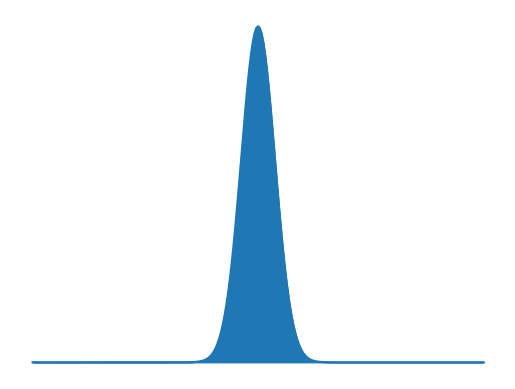

In [11]:
# YOU'RE WORKING ON THIS BOX!!!
t_f = 1.
t_snaps = 5
nh_min = omega.nh_min
shift = 0.45
shifts = shift * np.ones(nh_min + 1, float)
sigma, mu = WFT.GaussParams(x_0, x_1)
# sigma = 5 * sigma
t_f = (1. - (2. * mu)) / cs[0]
args = [sigma, mu]
field = 'B'
showParts = False
    



#waveInit = WFT.InitCond(omega, physics, WFT.Gauss, args)#, cellAve = False)
t = np.zeros(nh_min + 1)
js = [((nh_min / 4) - 2) / 3, ((nh_min / 2) + 1) / 3, nh_min / 4, (nh_min - 1) / 3, (((5 * nh_min) / 4) + 2) / 3]# nh_min / 2]#, ((2 * nh_min) + 1) / 3]#, (((5 * nh_min) / 2) + 2) / 3]
js = [int(j) for j in js]
print(js)
fig, ax = plt.subplots()
ax.axis('off')
ts = np.zeros((2, t_snaps), float)
xs = np.zeros((2, t_snaps), float)
us = np.zeros((2, t_snaps), float)

#     ax.set_xlim(-0.1, 1.2)
#     ax.set_ylim(-0.1, 0.21)
#     ax.set_zlim(-0.1, 0.7)

# for i in range(t_snaps):
t_val = (2 * t_f) / (t_snaps - 1)

if (showParts):
    wavePropI = 0.5 * WFT.WaveEq(omega, physics, WFT.Gauss, args, t_val, cellAve = False, IRT = 'I', field = field)
    wavePropT = 0.5 * WFT.WaveEq(omega, physics, WFT.Gauss, args, t_val, cellAve = False, IRT = 'T', field = field)
    wavePropR = 0.5 * WFT.WaveEq(omega, physics, WFT.Gauss, args, t_val, cellAve = False, IRT = 'R', field = field)
else:
    waveProp = 0.5 * WFT.WaveEq(omega, physics, WFT.Gauss, args, t_val, cellAve = False, field = field)

#     if (i == 0):
#         ts[0, :] = t_val * np.ones(t_snaps)
#         xs[0, :] = xNode[js]
#         print(waveProp)
#         print('')
#         us[0, :] = waveProp[js]
#     else:
#         if (i == t_snaps - 1):
#             ts[1, :] = t_val * np.ones(t_snaps)
#             xShift = WFT.ShiftX(omega, physics, -t_val)
#             xs[1, :] = xShift[js]
#             us[1, :] = us[0, :]
#     if (i == 1):
# print(np.shape(xNode))
# print(np.shape(waveProp))

if (showParts):
    ax.plot(xNode, wavePropI, color = PT.ColorDefault(0))#, zorder = 1)
    ax.fill_between(xNode, 0, wavePropI, color = PT.ColorDefault(0))
    ax.plot(xNode, wavePropT, color = PT.ColorDefault(2))#, zorder = 1)
    ax.fill_between(xNode, 0, wavePropT, color = PT.ColorDefault(2))
    ax.plot(xNode, wavePropR, color = PT.ColorDefault(4))#, zorder = 1)
    ax.fill_between(xNode, 0, wavePropR, color = PT.ColorDefault(4))
else:
    ax.plot(xNode, waveProp, color = PT.ColorDefault(0))#, zorder = 1)
    ax.fill_between(xNode, 0, waveProp, color = PT.ColorDefault(0))
    

    
plt.show()


[0.25       0.25195312 0.25390625 0.25585938 0.2578125  0.25976562 0.26171875 0.26367188 0.265625   0.26757812 0.26953125 0.27148438 0.2734375  0.27539062 0.27734375 0.27929688 0.28125    0.28320312 0.28515625 0.28710938 0.2890625  0.29101562 0.29296875 0.29492188 0.296875   0.29882812 0.30078125 0.30273438 0.3046875  0.30664062 0.30859375 0.31054688 0.3125     0.31445312 0.31640625 0.31835938 0.3203125  0.32226562 0.32421875 0.32617188 0.328125   0.33007812 0.33203125 0.33398438 0.3359375  0.33789062 0.33984375 0.34179688 0.34375    0.34570312 0.34765625 0.34960938 0.3515625  0.35351562 0.35546875 0.35742188 0.359375   0.36132812 0.36328125 0.36523438 0.3671875  0.36914062 0.37109375 0.37304688 0.375      0.37695312 0.37890625 0.38085938 0.3828125  0.38476562 0.38671875 0.38867188 0.390625   0.39257812 0.39453125 0.39648438 0.3984375  0.40039062 0.40234375 0.40429688 0.40625    0.40820312 0.41015625 0.41210938 0.4140625  0.41601562 0.41796875 0.41992188 0.421875   0.42382812 0.4257812

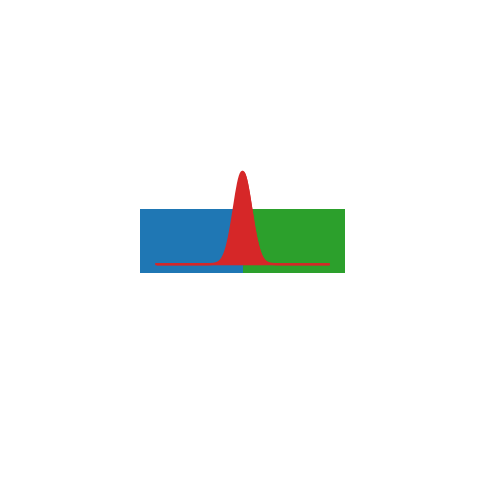

In [12]:
cond = 4

arrowLocX = 0.4
arrowLocY = 0.5
arrowLocY2 = arrowLocY

style = 'Round'
alpha = 0.3
if (cond == 1):
    boxWidth = 0.4
else:
    arrowLocX = 0.29
    boxWidth = 0.18
    if (cond == 3):
        arrowLocY = 0.525
    if (cond == 4):
        style = 'Square'
        alpha = 1
        
        
    
artist1 = mpatches.FancyBboxPatch((0.3, 0.45), boxWidth, 0.1, alpha = alpha, color = PT.ColorDefault(0), ec="none",
                            boxstyle=mpatches.BoxStyle(style, pad=0.02))
artist2 = mpatches.Arrow(arrowLocX, arrowLocY, 0.2, 0, width=0.1, color = PT.ColorDefault(0))

artist3 = mpatches.FancyBboxPatch((0.52, 0.45), boxWidth, 0.1, alpha = alpha, color = PT.ColorDefault(2), ec="none",
                            boxstyle=mpatches.BoxStyle(style, pad=0.02))

artist4 = mpatches.Arrow(0.51, arrowLocY2, 0.2, 0, width=0.1, color = PT.ColorDefault(2))

artist5 = mpatches.Arrow(0.49, 0.475, -0.2, 0, width=0.1, color = PT.ColorDefault(4))

# axs = plt.figure(figsize=(6, 6)).subplots(3, 3)
fig, ax = plt.subplots(figsize = [6, 6])
# for i, (ax, artist) in enumerate(zip(axs.flat, artists)):
ax.add_artist(artist1)
if (cond != 4):
    ax.add_artist(artist2)
if (cond != 1):
    ax.add_artist(artist3)
    if (cond != 4):
        ax.add_artist(artist4)
        if (cond == 3):
            ax.add_artist(artist5)
if (cond == 4):
    waveProp = (0.4 * waveProp) + shift
    a = 2
    b = 0.5 - (0.5 / a)
    xNodeFix = (xNode / a) + b
    print(xNodeFix)
    c = 33
    d = nh_min - c + 1
    ax.plot(xNodeFix[c:d], waveProp[c:d], color = PT.ColorDefault(3), zorder = 3)
    ax.fill_between(xNodeFix[c:d], shifts[c:d], waveProp[c:d], color = PT.ColorDefault(3), zorder = 3)
# ax.set(aspect=1, xlim=(-.2, .2), ylim=(-.2, .2))
ax.axis('off')
# ax.grid(True)
plt.xlim(0, 1)
plt.ylim(0, 1)

plt.show()

saveName = '/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/Figures/icon' + str(cond) # + appendage
fig.savefig(saveName + '.png', bbox_inches = 'tight', dpi = 600, transparent = True)
    


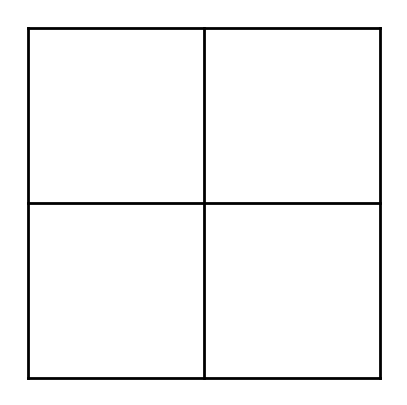

In [13]:
savePath = '/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/Figures/'
numPoints = 17
x = linspace(0, 1, num = numPoints)
y = np.ones(numPoints)
offset = 0.03125
bigness = 5
lw = 2


# plt.rcParams['axes.linewidth'] = lw # set the value globally

fig, ax = plt.subplots(figsize = (bigness, bigness))
ax = plt.plot(x, 0 * x, color = 'k', linewidth = lw)
ax = plt.plot(0 * x, x, color = 'k', linewidth = lw)
ax = plt.plot(x, y, color = 'k', linewidth = lw)
ax = plt.plot(y, x, color = 'k', linewidth = lw)

ax = plt.plot(x, 0.5 * y, color = 'k', linewidth = lw)
ax = plt.plot(0.5 * y, x, color = 'k', linewidth = lw)
# plt.text(0.75 - offset, 0.25 - offset, r'$\Omega^{(0)}$', fontsize = 15)
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.tick_params(axis = 'x', which = 'both', bottom = False, top = False, labelbottom = False)
plt.tick_params(axis = 'y', which = 'both', left = False, right = False, labelleft = False)
figName = 'AMR1'
plt.axis('off')
plt.show()
fig.savefig(savePath + figName + '.png', bbox_inches = 'tight', dpi = 300, transparent = True)




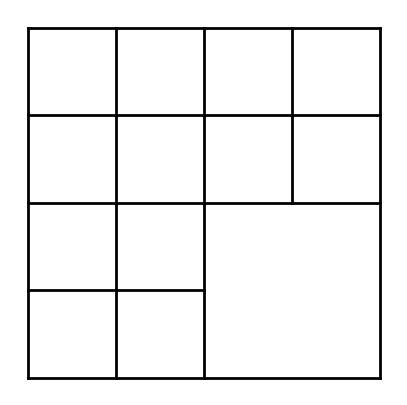

In [14]:
fig, ax = plt.subplots(figsize = (bigness, bigness))
ax = plt.plot(x, 0 * x, color = 'k', linewidth = lw)
ax = plt.plot(0 * x, x, color = 'k', linewidth = lw)
ax = plt.plot(x, y, color = 'k', linewidth = lw)
ax = plt.plot(y, x, color = 'k', linewidth = lw)

ax = plt.plot(x, 0.5 * y, color = 'k', linewidth = lw)
ax = plt.plot(0.5 * y, x, color = 'k', linewidth = lw)

ax = plt.plot(x, (0.25 * y) + 0.5, color = 'k', linewidth = lw)
ax = plt.plot(0.25 * y, x, color = 'k', linewidth = lw)
ax = plt.plot(0.75 * y, (0.5 * x) + 0.5, color = 'k', linewidth = lw)
plt.plot(0.5 * x, 0.25 * y, color = 'k', linewidth = lw)

# plt.text(0.35 - offset, 0.625 - offset, r'$\Omega^{(1)}$', fontsize = 15)

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.tick_params(axis = 'x', which = 'both', bottom = False, top = False, labelbottom = False)
plt.tick_params(axis = 'y', which = 'both', left = False, right = False, labelleft = False)
figName = 'AMR2'
plt.axis('off')
plt.show()


fig.savefig(savePath + figName + '.png', bbox_inches = 'tight', dpi = 300, transparent = True)



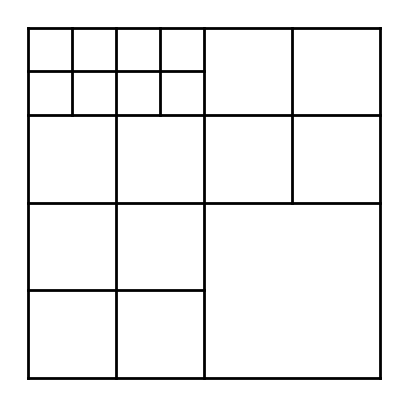

In [15]:
fig, ax = plt.subplots(figsize = (bigness, bigness))
ax = plt.plot(x, 0 * x, color = 'k', linewidth = lw)
ax = plt.plot(0 * x, x, color = 'k', linewidth = lw)
ax = plt.plot(x, y, color = 'k', linewidth = lw)
ax = plt.plot(y, x, color = 'k', linewidth = lw)

ax = plt.plot(x, 0.5 * y, color = 'k', linewidth = lw)
ax = plt.plot(0.5 * y, x, color = 'k', linewidth = lw)

ax = plt.plot(x, (0.25 * y) + 0.5, color = 'k', linewidth = lw)
ax = plt.plot(0.25 * y, x, color = 'k', linewidth = lw)
ax = plt.plot(0.75 * y, (0.5 * x) + 0.5, color = 'k', linewidth = lw)
ax = plt.plot(0.5 * x, 0.25 * y, color = 'k', linewidth = lw)

ax = plt.plot(0.5 * x, (0.125 * y) + 0.75, color = 'k', linewidth = lw)
ax = plt.plot((0.125 * y), (0.25 * x) + 0.75, color = 'k', linewidth = lw)
ax = plt.plot((0.125 * y) + 0.25, (0.25 * x) + 0.75, color = 'k', linewidth = lw)

# plt.text(0.165 - offset, 0.8125 - offset, r'$\Omega^{(2)}$', fontsize = 15)

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.tick_params(axis = 'x', which = 'both', bottom = False, top = False, labelbottom = False)
plt.tick_params(axis = 'y', which = 'both', left = False, right = False, labelleft = False)
figName = 'AMR3'
plt.axis('off')
plt.show()

fig.savefig(savePath + figName + '.png', bbox_inches = 'tight', dpi = 300, transparent = True)



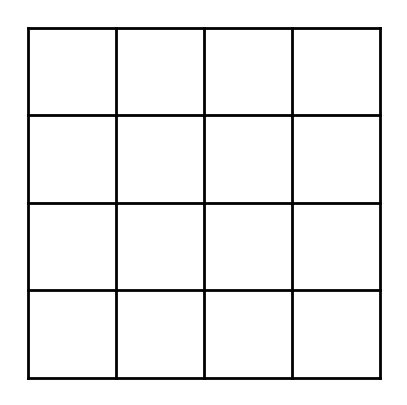

In [16]:
savePath = '/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/Figures/'
numPoints = 17
x = linspace(0, 1, num = numPoints)
y = np.ones(numPoints)
offset = 0.03125
bigness = 5
lw = 2


# plt.rcParams['axes.linewidth'] = lw # set the value globally

fig, ax = plt.subplots(figsize = (bigness, bigness))
ax = plt.plot(x, 0 * x, color = 'k', linewidth = lw)
ax = plt.plot(0 * x, x, color = 'k', linewidth = lw)
ax = plt.plot(x, y, color = 'k', linewidth = lw)
ax = plt.plot(y, x, color = 'k', linewidth = lw)

for i in range(3):
    a = (i + 1) * 0.25
    ax = plt.plot(x, a * y, color = 'k', linewidth = lw)
    ax = plt.plot(a * y, x, color = 'k', linewidth = lw)
# plt.text(0.75 - offset, 0.25 - offset, r'$\Omega^{(0)}$', fontsize = 15)
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.tick_params(axis = 'x', which = 'both', bottom = False, top = False, labelbottom = False)
plt.tick_params(axis = 'y', which = 'both', left = False, right = False, labelleft = False)
figName = 'Uniform2'
plt.axis('off')
plt.show()
fig.savefig(savePath + figName + '.png', bbox_inches = 'tight', dpi = 300, transparent = True)


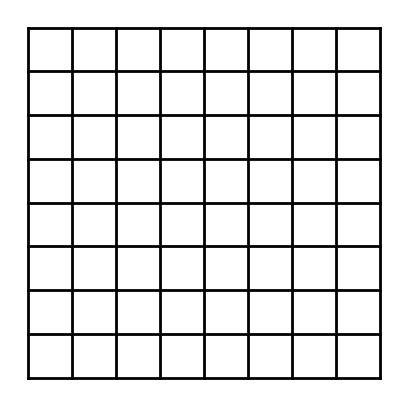

In [17]:
savePath = '/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/Figures/'
numPoints = 17
x = linspace(0, 1, num = numPoints)
y = np.ones(numPoints)
offset = 0.03125
bigness = 5
lw = 2


# plt.rcParams['axes.linewidth'] = lw # set the value globally

fig, ax = plt.subplots(figsize = (bigness, bigness))
ax = plt.plot(x, 0 * x, color = 'k', linewidth = lw)
ax = plt.plot(0 * x, x, color = 'k', linewidth = lw)
ax = plt.plot(x, y, color = 'k', linewidth = lw)
ax = plt.plot(y, x, color = 'k', linewidth = lw)

for i in range(7):
    a = (i + 1) * 0.125
    ax = plt.plot(x, a * y, color = 'k', linewidth = lw)
    ax = plt.plot(a * y, x, color = 'k', linewidth = lw)
# plt.text(0.75 - offset, 0.25 - offset, r'$\Omega^{(0)}$', fontsize = 15)
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.tick_params(axis = 'x', which = 'both', bottom = False, top = False, labelbottom = False)
plt.tick_params(axis = 'y', which = 'both', left = False, right = False, labelleft = False)
figName = 'Uniform3'
plt.axis('off')
plt.show()
fig.savefig(savePath + figName + '.png', bbox_inches = 'tight', dpi = 300, transparent = True)


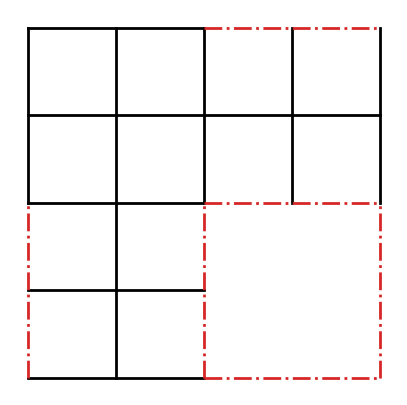

In [18]:
LS = '-.'
color = PT.ColorDefault(3)

fig, ax = plt.subplots(figsize = (bigness, bigness))
ax = plt.plot(0.5 * x, 0 * x, color = 'k', linewidth = lw, zorder = 0)
ax = plt.plot(0.5 * x + 0.5, 0 * x, color = color, linewidth = lw, linestyle = LS, zorder = 1)
ax = plt.plot(0 * x, 0.5 * x + 0.5, color = 'k', linewidth = lw, zorder = 0)
ax = plt.plot(0 * x, 0.5 * x, color = color, linewidth = lw, linestyle = LS, zorder = 1)
ax = plt.plot(0.5 * x, y, color = 'k', linewidth = lw, zorder = 0)
ax = plt.plot(0.5 * x + 0.5, y, color = color, linewidth = lw, linestyle = LS, zorder = 1)
ax = plt.plot(y, 0.5 * x + 0.5, color = 'k', linewidth = lw, zorder = 0)
ax = plt.plot(y, 0.5 * x, color = color, linewidth = lw, linestyle = LS, zorder = 1)

ax = plt.plot(0.5 * x, 0.5 * y, color = 'k', linewidth = lw, zorder = 0)
ax = plt.plot(0.5 * x + 0.5, 0.5 * y, color = color, linewidth = lw, linestyle = LS, zorder = 1)
ax = plt.plot(0.5 * y, 0.5 * x + 0.5, color = 'k', linewidth = lw, zorder = 0)
ax = plt.plot(0.5 * y, 0.5 * x, color = color, linewidth = lw, linestyle = LS, zorder = 1)

ax = plt.plot(x, (0.25 * y) + 0.5, color = 'k', linewidth = lw, zorder = 0)
ax = plt.plot(0.25 * y, x, color = 'k', linewidth = lw, zorder = 0)
ax = plt.plot(0.75 * y, (0.5 * x) + 0.5, color = 'k', linewidth = lw, zorder = 0)
plt.plot(0.5 * x, 0.25 * y, color = 'k', linewidth = lw, zorder = 0)

# plt.text(0.35 - offset, 0.625 - offset, r'$\Omega^{(1)}$', fontsize = 15)

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.tick_params(axis = 'x', which = 'both', bottom = False, top = False, labelbottom = False)
plt.tick_params(axis = 'y', which = 'both', left = False, right = False, labelleft = False)
figName = 'AMRBound2'
plt.axis('off')
plt.show()


fig.savefig(savePath + figName + '.png', bbox_inches = 'tight', dpi = 300, transparent = True)

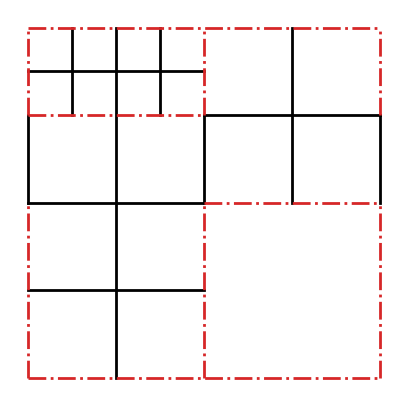

In [19]:
fig, ax = plt.subplots(figsize = (bigness, bigness))
ax = plt.plot(x, 0 * x, color = color, linewidth = lw, linestyle = LS, zorder = 1)
ax = plt.plot(0 * x, 0.25 * x + 0.5, color = 'k', linewidth = lw, zorder = 0)
ax = plt.plot(0 * x, 0.25 * x + 0.75, color = color, linewidth = lw, linestyle = LS, zorder = 1)
ax = plt.plot(0 * x, 0.5 * x, color = color, linewidth = lw, linestyle = LS, zorder = 1)
ax = plt.plot(x, y, color = color, linestyle = LS, linewidth = lw, zorder = 1)
ax = plt.plot(y, 0.25 * x + 0.5, color = 'k', linewidth = lw, zorder = 0)
ax = plt.plot(y, 0.25 * x + 0.75, color = color, linewidth = lw, linestyle = LS, zorder = 1)
ax = plt.plot(y, 0.5 * x, color = color, linewidth = lw, linestyle = LS, zorder = 1)

ax = plt.plot(0.5 * x, 0.5 * y, color = 'k', linewidth = lw, zorder = 0)
ax = plt.plot(0.5 * x + 0.5, 0.5 * y, color = color, linewidth = lw, linestyle = LS, zorder = 1)
ax = plt.plot(0.5 * y, 0.25 * x + 0.5, color = 'k', linewidth = lw, zorder = 0)
ax = plt.plot(0.5 * y, 0.25 * x + 0.75, color = color, linewidth = lw, linestyle = LS, zorder = 1)
ax = plt.plot(0.5 * y, 0.5 * x, color = color, linewidth = lw, linestyle = LS, zorder = 1)

ax = plt.plot(0.5 * x, (0.125 * y) + 0.75, color = 'k', linewidth = lw, zorder = 0)
ax = plt.plot((0.125 * y), (0.25 * x) + 0.75, color = 'k', linewidth = lw, zorder = 0)
ax = plt.plot((0.125 * y) + 0.25, (0.25 * x) + 0.75, color = 'k', linewidth = lw, zorder = 0)

ax = plt.plot(0.5 * x + 0.5, (0.25 * y) + 0.5, color = 'k', linewidth = lw, zorder = 0)
ax = plt.plot(0.5 * x, (0.25 * y) + 0.5, color = color, linewidth = lw, linestyle = LS, zorder = 1)
ax = plt.plot(0.25 * y, x, color = 'k', linewidth = lw, zorder = 0)
ax = plt.plot(0.75 * y, (0.5 * x) + 0.5, color = 'k', linewidth = lw, zorder = 0)
plt.plot(0.5 * x, 0.25 * y, color = 'k', linewidth = lw, zorder = 0)

# plt.text(0.35 - offset, 0.625 - offset, r'$\Omega^{(1)}$', fontsize = 15)

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.tick_params(axis = 'x', which = 'both', bottom = False, top = False, labelbottom = False)
plt.tick_params(axis = 'y', which = 'both', left = False, right = False, labelleft = False)
figName = 'AMRBound3'
plt.axis('off')
plt.show()


fig.savefig(savePath + figName + '.png', bbox_inches = 'tight', dpi = 300, transparent = True)

In [20]:
nh_min = 4
refRatio = 2

cells = list(np.arange(2))

In [21]:
omega2 = BT.Grid(nh_min)
omega2.AddPatch(refRatio, cells)

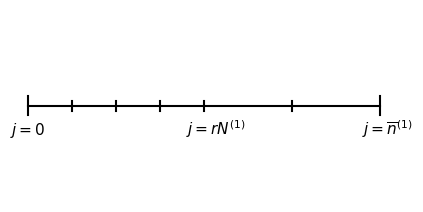

In [22]:
PT.PlotGrid(omega2)


In [23]:
# x = np.arange(33)
# print(x)
# print(x[::4])
# x = x[np.mod(np.arange(x.size), 4) != 0]
# print(x)
# print(256/24)
# print('')

In [24]:
A = np.arange(11)
c = 2
d = 11 - 2
print(A)
print(A[c:d])
print('')

[ 0  1  2  3  4  5  6  7  8  9 10]
[2 3 4 5 6 7 8]

